# EDA Healthcare Project


In [23]:
import sys
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install ydata-profiling


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.17.0 Requires-Python >=3.7,<3.14; 4.18.0 Requires-Python >=3.10,<3.14; 4.18.1 Requires-Python >=3.10,<3.14; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requ

In [24]:
import sys
!{sys.executable} -m pip install seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [26]:
patients = pd.read_csv(r"E:\Medical_Healthcare_Project\output\csv\patients.csv")
encounters = pd.read_csv(r"E:\Medical_Healthcare_Project\output\csv\encounters.csv")
conditions = pd.read_csv(r"E:\Medical_Healthcare_Project\output\csv\conditions.csv")
claims = pd.read_json(r"E:\Medical_Healthcare_Project\output\claims.json")

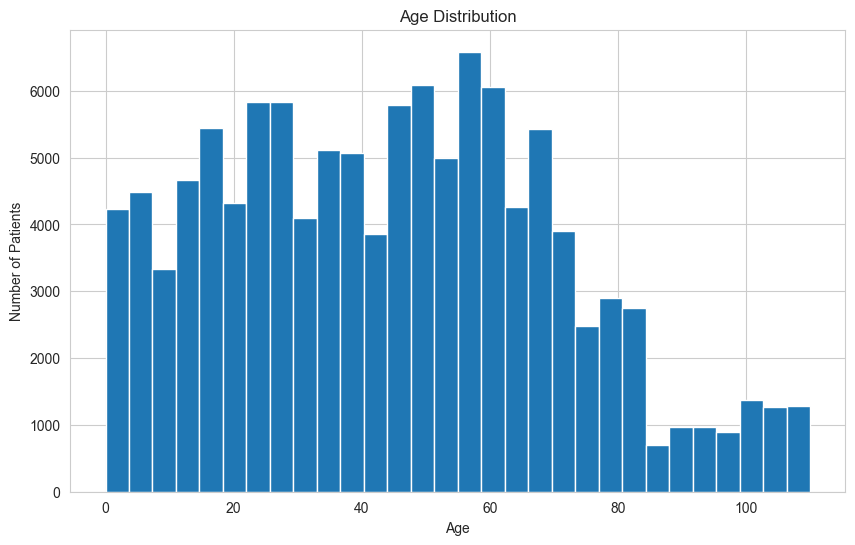

In [27]:
# 1- Demograohics Analysis

# 1.1 >>>>> Age Distripution

patients["BIRTHDATE"] = pd.to_datetime(patients["BIRTHDATE"])
patients["age"] = (pd.Timestamp.now() - patients["BIRTHDATE"]).dt.days // 365

plt.hist(patients["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

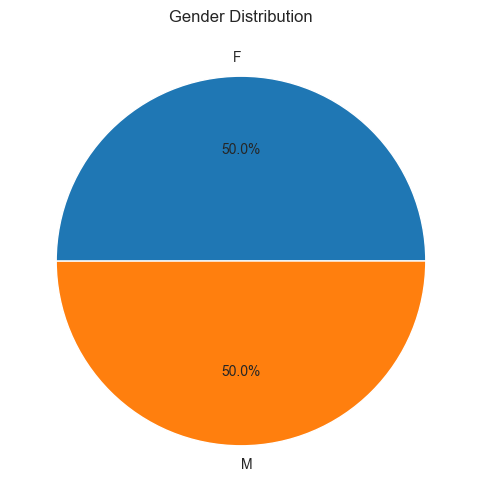

In [28]:

# 1.2 >>>>> Gender Ratio

gender_counts = patients["GENDER"].value_counts()

plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

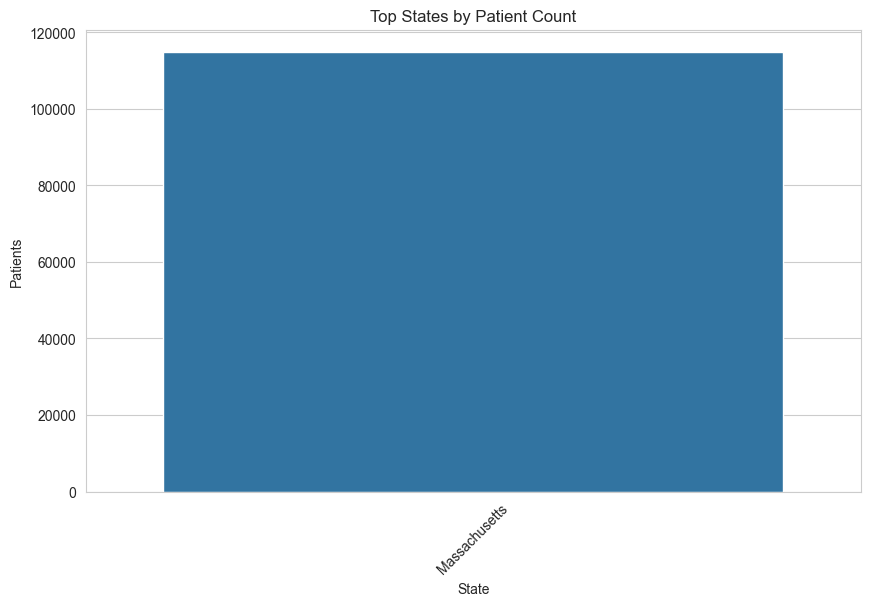

In [29]:

#1.3 >>>>> Geografhic Distribution

location_counts = patients["STATE"].value_counts().head(10)

sns.barplot(x=location_counts.index, y=location_counts.values)
plt.title("Top States by Patient Count")
plt.xlabel("State")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.show()


# لو فريت في الداتا بتاع العيانين اللي اتولدت هما كلهم من ولاية واحدة أصلا

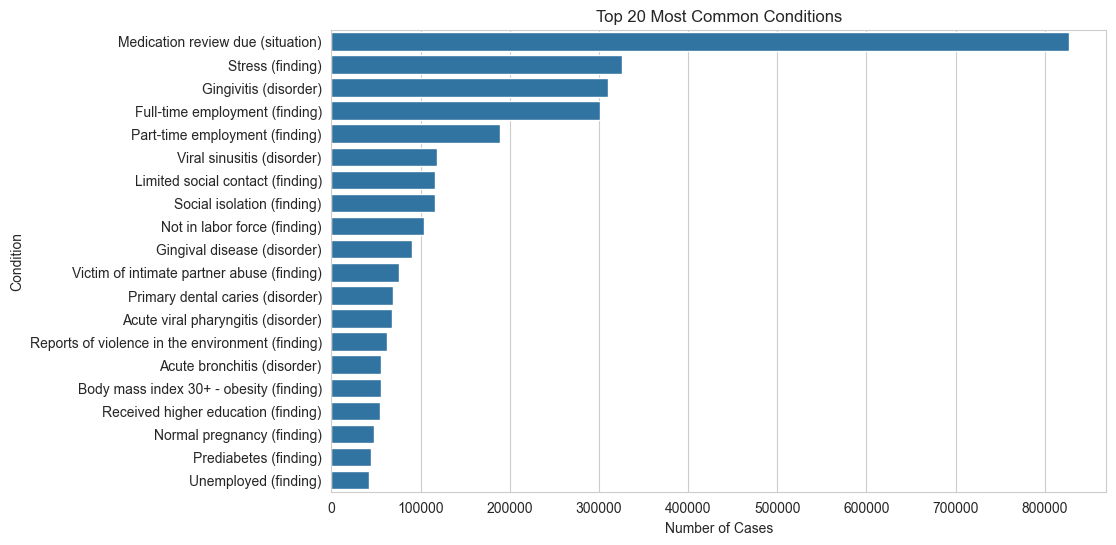

In [30]:

# 2- Clinical Patterns

# 2.1 >>>>> Top 20 Conditions by Prevalence

top_conditions = (
    conditions["DESCRIPTION"]
    .value_counts()
    .head(20)
)

sns.barplot(
    y=top_conditions.index,
    x=top_conditions.values
)

plt.title("Top 20 Most Common Conditions")
plt.xlabel("Number of Cases")
plt.ylabel("Condition")
plt.show()

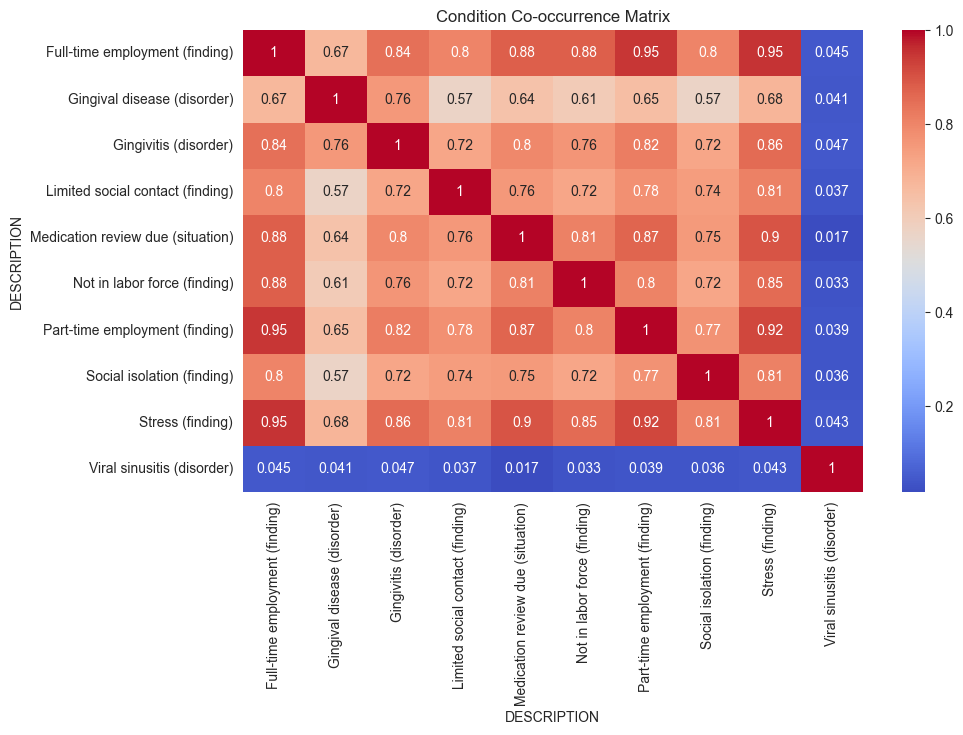

In [31]:

# 2.2 >>>>>>> Condition Co-Occurrence matrix (Heatmap)

# نخلي الشغل على التوب 10 لأني اشتغلت على التوب 20 زي اللي قبلها بس الخريطة طلعت مش متشاف فيها حاجة

top10 = conditions["DESCRIPTION"].value_counts().head(10).index

filtered = conditions[conditions["DESCRIPTION"].isin(top10)]

# جدول يوضح هل المريض عنده المرض ولا لا
patient_condition_matrix = pd.crosstab(
    filtered["PATIENT"],
    filtered["DESCRIPTION"]
)

# نحسب correlation بين الأمراض
correlation_matrix = patient_condition_matrix.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Condition Co-occurrence Matrix")
plt.show()